In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import h5py
from scipy.sparse import csc_matrix
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


# Results from SIngleR implemneted in R

In [187]:
adata_singleR = sc.read_h5ad(f"D:/ankita/Mouse adipose/adata_annotated.h5ad")

In [188]:
adata_singleR


AnnData object with n_obs × n_vars = 10124 × 5006
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'timepoint', 'nCount_RNA_log', 'nFeature_RNA_log', 'RNA_snn_res.0.6', 'seurat_clusters', 'tsne_1', 'tsne_2', 'predicted.id', 'prediction.score.dendritic.cell', 'prediction.score.macrophage', 'prediction.score.monocyte', 'prediction.score.mature.NK.T.cell', 'prediction.score.T.cell', 'prediction.score.B.cell', 'prediction.score.mast.cell', 'prediction.score.neutrophil', 'prediction.score.max', 'SingleR_label'
    obsm: 'X_pca', 'X_umap'

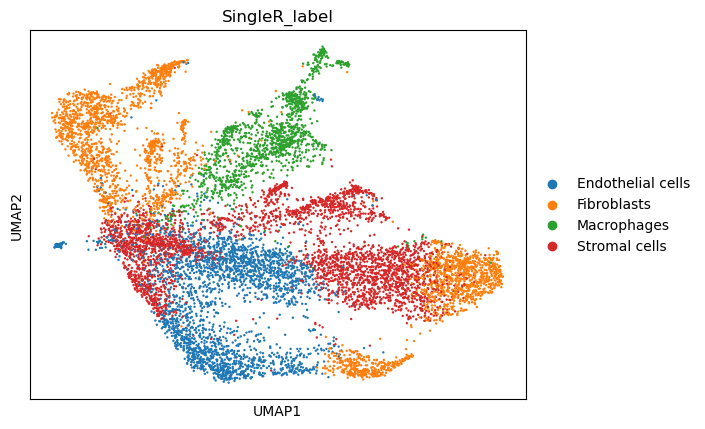

In [189]:
sc.pl.umap(adata_singleR, color=[ "SingleR_label"])

In [190]:
import matplotlib.pyplot as plt
fig=sc.pl.umap(adata_singleR,color='SingleR_label',show=False,return_fig=True)
fig.savefig(
    "singleR.pdf",
    bbox_inches="tight"
)

plt.close(fig)

In [633]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

score = silhouette_score(adata_singleR.obsm["X_pca"], adata_singleR.obs["seurat_clusters"])
print("Silhoutte Score:", score)

X = adata_singleR.obsm["X_pca"]
labels = adata_singleR.obs["seurat_clusters"].astype(str)

chi_score = calinski_harabasz_score(X, labels)
dbi_score = davies_bouldin_score(X, labels)

print("Calinski-Harabasz Index:", chi_score)
print("Davies-Bouldin Index:", dbi_score)

Silhoutte Score: -0.009547357189475572
Calinski-Harabasz Index: 883.6081422654163
Davies-Bouldin Index: 1.702155723818011
